In [160]:
import pandas as pd # Ref:https://pandas.pydata.org/
import requests 
import numpy as np
import matplotlib.pyplot as plt # Ref:https://matplotlib.org/
import seaborn as sns # Ref:https://seaborn.pydata.org/

from pathlib import Path

plt.style.use('default') # sets matplotlib to use default plotting style
sns.set_context('talk') # Used for clarity in project



In [161]:
# Part 1 - Importing and Cleaning Data 

In [162]:
# Due to the structure of Met Eireanns data, I chose 5 stations to analyse rainfall and wind trends in Ireland
# I tried to use stations from various parts of Irealnd for the data presented to be more accurate

stations = {"Cork Airport": "cork%20airport",
            "Dublin Airport": "dublin%20airport",
            "Shannon Airport": "shannon%20airport",
            "Knock Airport": "knock%20airport",
            "Valentia Observatory": "valentia%20observatory" }

In [163]:
# Fetch and clean rainfall data
# Ref: https://data.gov.ie/organization/meteireann?res_format=JSON&tags=Monthly
# Ref example for station: https://data.gov.ie/dataset/monthly-weather-valentia-observatory

def fetch_rainfall_data(station_name, station_url):
    url = f'https://prodapi.metweb.ie/monthly-data/{station_url}' # I used available JSON data for each station
    response = requests.get(url)
    data = response.json()

    rainfall = data['total_rainfall']['report']

    records =[]

    for year in ['2024', '2025']:
        if year in rainfall:
            for month, value in rainfall[year].items():
                if month != 'annual' and value not in ['','n/a']:
                    records.append({
                        'station': station_name,
                        'year': int(year),
                        'month': month,
                        'rainfall_mm': float(value)

                })
                    
    return pd.DataFrame(records)


In [164]:
# Pull data from all stations

df_list = []

for station_name, station_url in stations.items():
    df_station = fetch_rainfall_data (station_name, station_url)
    df_list.append(df_station)

rainfall_df = pd.concat(df_list, ignore_index=True)

In [165]:
# Inspet the result to prevent errors

print(rainfall_df.info())
rainfall_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   station      120 non-null    object 
 1   year         120 non-null    int64  
 2   month        120 non-null    object 
 3   rainfall_mm  120 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.9+ KB
None


,station,year,month,rainfall_mm
0,Cork Airport,2024,january,99.5
1,Cork Airport,2024,february,157.7
2,Cork Airport,2024,mar,168.2
3,Cork Airport,2024,apr,107.1
4,Cork Airport,2024,may,109.6


In [166]:
# Part 2 - Comparing 2024 vs 2025 for each station 

In [167]:
# Compare 2024 vs 2025 for each station

yearly_comparison = (
    rainfall_df
    .groupby(['station', 'year'])['rainfall_mm']
    .mean()
    .reset_index()
)

yearly_comparison

,station,year,rainfall_mm
0,Cork Airport,2024,105.833333
1,Cork Airport,2025,114.366667
2,Dublin Airport,2024,55.833333
3,Dublin Airport,2025,67.016667
4,Knock Airport,2024,119.175000
5,Knock Airport,2025,114.583333
6,Shannon Airport,2024,81.150000
7,Shannon Airport,2025,85.666667
8,Valentia Observatory,2024,137.691667
9,Valentia Observatory,2025,150.783333


In [168]:
# 4 out of the 5 stations shows more rainfall in 2025 compared to 2024

In [169]:
# Part 3 - Indentify extreme rainfall months

In [170]:
# Used Lambda for easier use of functions
# Ref:https://www.w3schools.com/python/python_lambda.asp

threshold = rainfall_df['rainfall_mm'].quantile(0.90)

extreme_rainfall = (

 rainfall_df
 .groupby('station', group_keys=False)
 .apply(lambda x: x[x['rainfall_mm'] >= x['rainfall_mm'].quantile(0.90)]) 
)

extreme_rainfall = extreme_rainfall.sort_values(
    by=['station', 'year', 'rainfall_mm'],
    ascending=[True, True, False]
)


extreme_rainfall

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16484\606273716.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x[x['rainfall_mm'] >= x['rainfall_mm'].quantile(0.90)])


,station,year,month,rainfall_mm
13,Cork Airport,2025,february,213.4
22,Cork Airport,2025,november,203.7
21,Cork Airport,2025,october,176.5
26,Dublin Airport,2024,mar,115.4
46,Dublin Airport,2025,november,119.1
44,Dublin Airport,2025,september,91.4
79,Knock Airport,2024,august,215.4
93,Knock Airport,2025,october,175.0
92,Knock Airport,2025,september,173.5
49,Shannon Airport,2024,february,156.5


In [171]:
# Part 4 - Visualise data using matplotlib

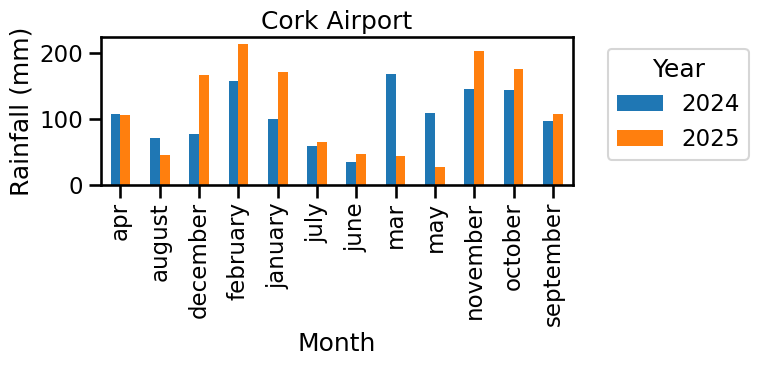

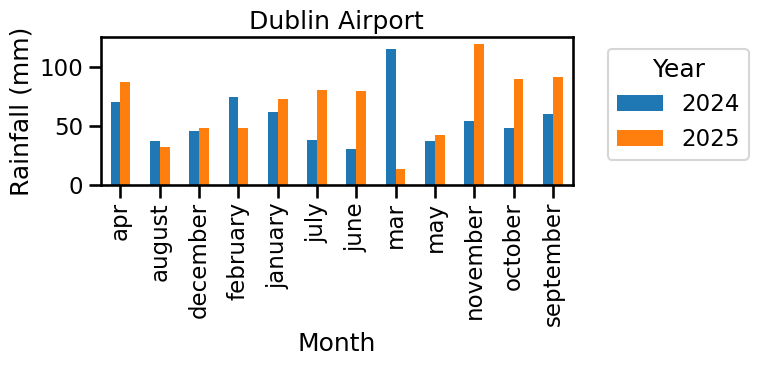

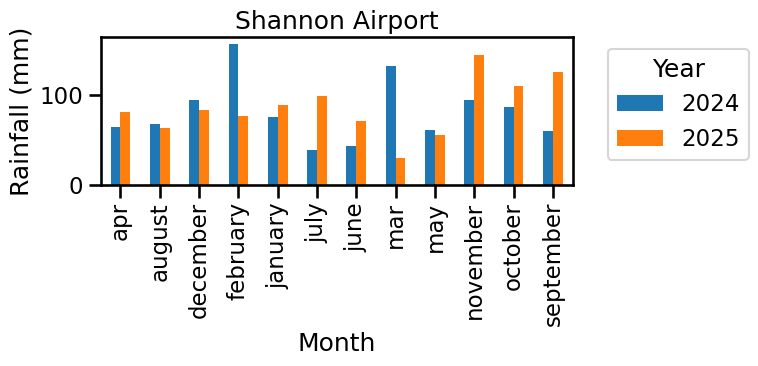

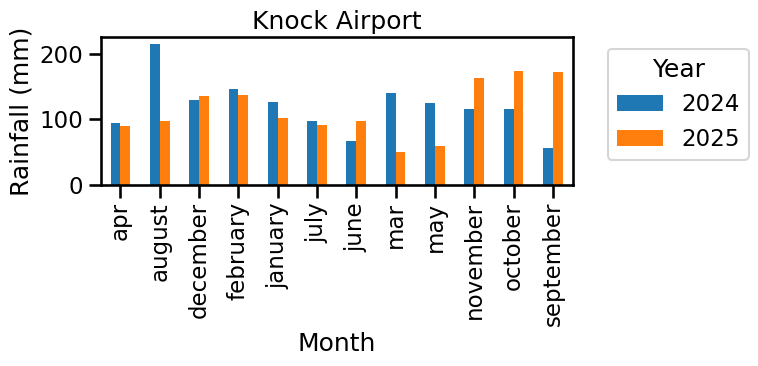

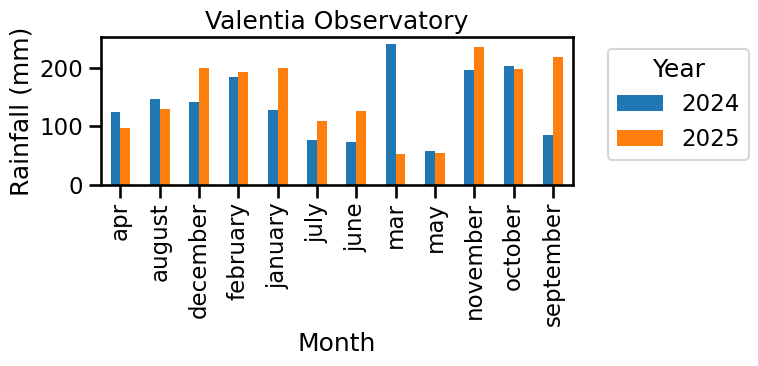

In [172]:
# Ref:https://matplotlib.org/

for station in rainfall_df['station'].unique():
    subset = rainfall_df[rainfall_df['station'] == station]

    pivot = subset.pivot(
        index='month',
        columns='year',
        values='rainfall_mm'
    )

    ax = pivot.plot(kind='bar', figsize=(8,4), title=station)

    ax.set_ylabel('Rainfall (mm)')
    ax.set_xlabel('Month')

# Forcing legend to stay to right side as cork graph was showing in middle
    ax.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()


In [173]:
# Part 6 - Monthly Rainfall Trend Analysis for Five Stations Using Line Graphs and compare full year mean monthly rainfall in MM

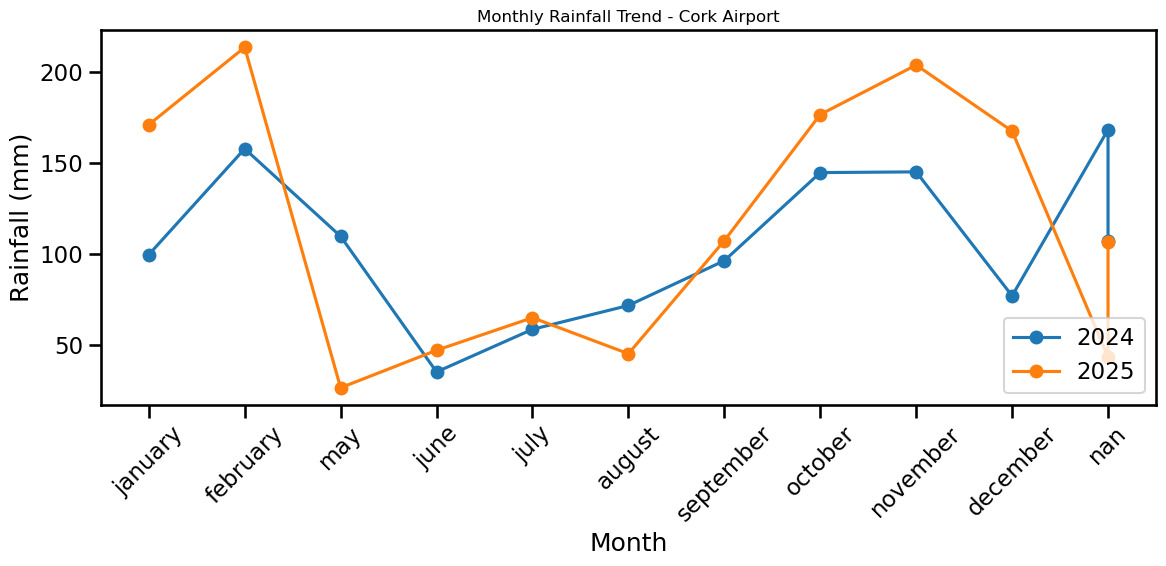

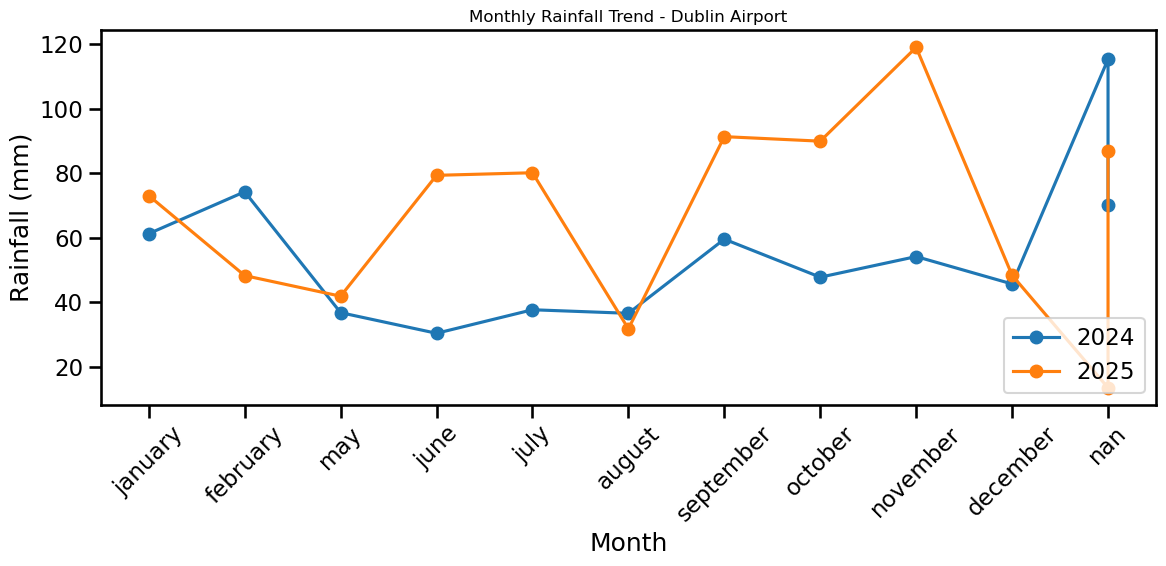

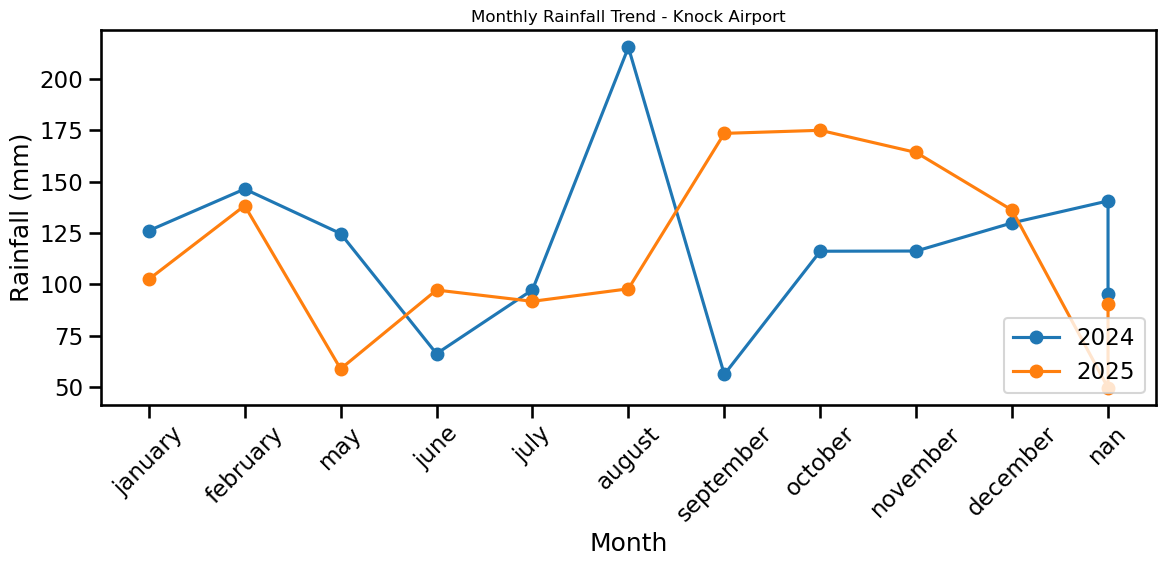

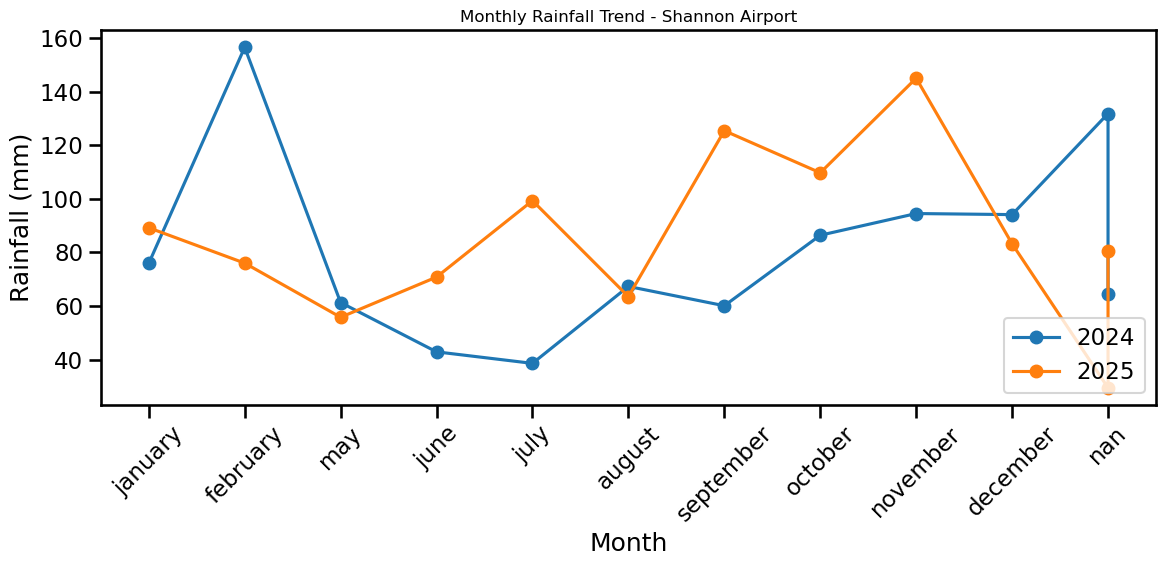

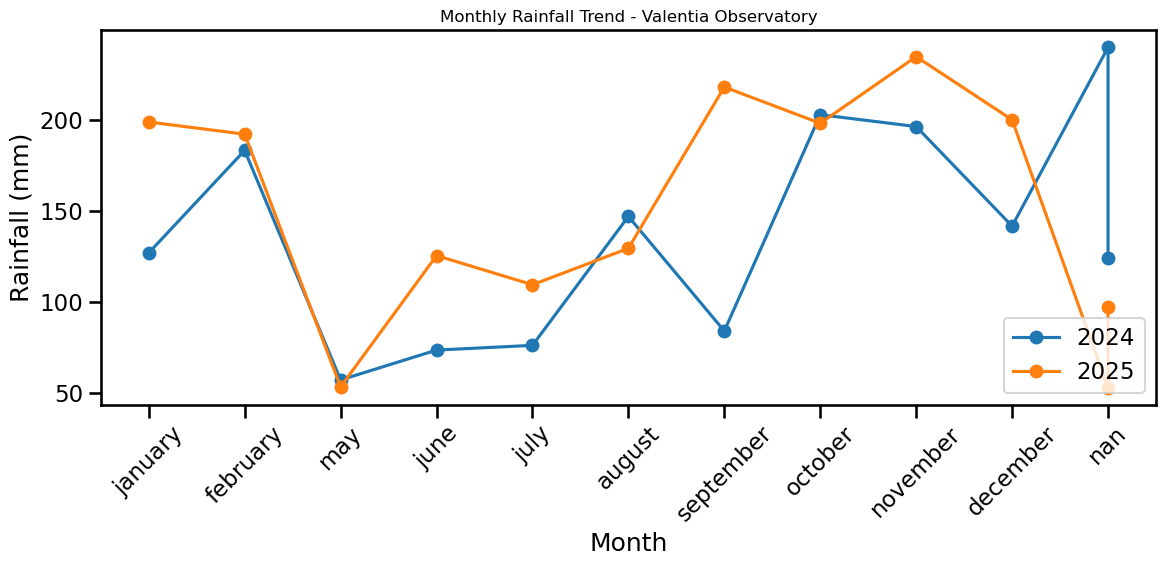

In [174]:
# Ordering all month columns 
# Using notna function as error with missing values
# Ref:https://www.w3schools.com/python/pandas/ref_df_notna.asp

rainfall_df = rainfall_df[rainfall_df['month'].notna() & rainfall_df['rainfall_mm'].notna()].copy()
rainfall_df['month'] = rainfall_df['month'].astype(str).str.lower()

# Checking months in correct order
month_order =['january','february','march','april','may','june','july','august','september','october','november','december']

rainfall_df['month'] = pd.Categorical(
    rainfall_df['month'],
    categories=month_order,
    ordered=True
)

# Sort by month for plotting
rainfall_df = rainfall_df.sort_values(['station', 'year', 'month'])

# Plotting Monthly Rainfall Trends for Each Station
for station in rainfall_df['station'].unique():
    subset = rainfall_df[rainfall_df['station'] == station]

    plt.figure(figsize=(12,6))
    
    for year in sorted(subset['year'].unique()):
        yearly = subset[subset['year'] == year]
        plt.plot(
            yearly['month'].astype(str),
            yearly['rainfall_mm'],
            marker='o',
            label=str(year)
        )


    plt.title(f'Monthly Rainfall Trend - {station}', fontsize=12)
    plt.xlabel('Month')
    plt.ylabel('Rainfall (mm)')
    plt.xticks(rotation=45)
    plt.legend( loc ='lower right') # Forced legend to stay in bottom right as some generated in the middle
    plt.tight_layout()
    plt.show()


In [175]:
# Results show more rainfall overall in 2025
national_summary = (
    rainfall_df
    .groupby('year')['rainfall_mm']
    .mean()
    .reset_index(name='mean_monthly_rainfall_mm')
)

national_summary

,year,mean_monthly_rainfall_mm
0,2024,99.936667
1,2025,106.483333


In [176]:
# Part 7 - Compare all factors in relation to Insurance cost and plot Bar Chart and Line Chart to present data

In [177]:
# Identify extreme reainfall months for comparsion between insurance cost
extreme_threshold = rainfall_df['rainfall_mm'].quantile(0.90)

extreme_months = rainfall_df[
    rainfall_df['rainfall_mm'] >= extreme_threshold
]

# Count extreme weather months per year
extreme_counts = ( 
    extreme_months
    .groupby('year')
    .size()
    .reset_index(name='extreme_rainfall_months')
)

In [178]:
# Based on CSO index there has been a increase in premium prices of 7.5% between 2024-2025
# I will use this figure to convert reported increase into an index
# Ref: https://www.cso.ie/en/releasesandpublications/ep/p-yin/ireland2025theyearinnumbers/2025highlights/
# Ref: https://www.oireachtas.ie/en/debates/question/2025-04-08/359/

premium_index = pd.DataFrame({
    'year': [2024, 2025],
    'premium_index': [100, 107.5]
})


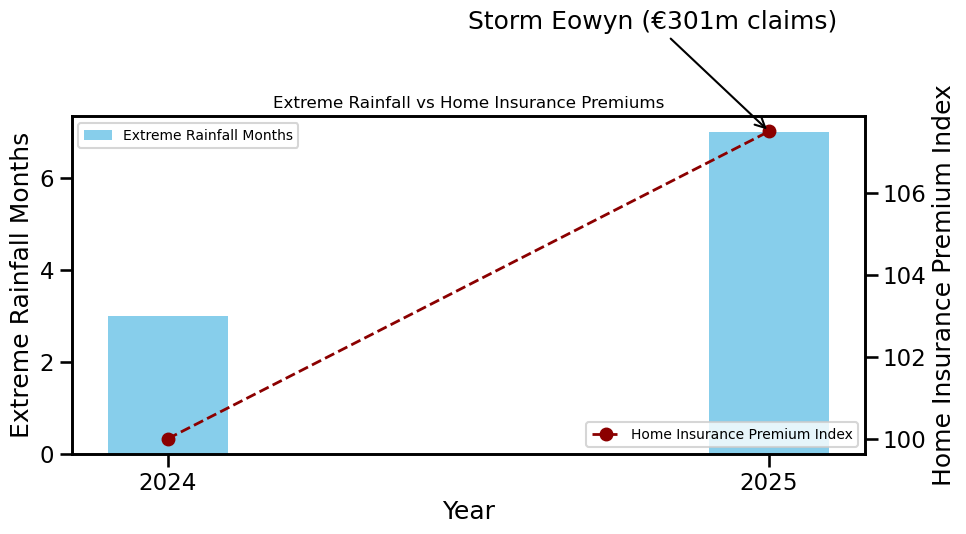

In [194]:
# To present data I used a Bar Chart to show extreme rainfall months
# Line Chart to show Insurance Premium Index
# Used combined fucntion to present data

combined = pd.DataFrame({
    'year': [2024,2025],
    'extreme_rainfall_months': [3, 7],
    'premium_index': [100, 107.5]
})

fig, ax1 = plt.subplots(figsize=(10,6))

# Bar Chart Plot
bars = ax1.bar(combined['year'], combined['extreme_rainfall_months'], color='skyblue', width=0.2, label= 'Extreme Rainfall Months')
ax1.set_xlabel('Year')
ax1.set_ylabel('Extreme Rainfall Months', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xticks(combined['year'])

# Line Chart for Insurance Premium
ax2 = ax1.twinx()
ax2.plot(combined['year'], combined['premium_index'], color='darkred',marker='o', linestyle ='--',linewidth=2, label='Home Insurance Premium Index')
ax2.set_ylabel('Home Insurance Premium Index', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Include Storm Eowyn and annotate of graph
# Ref:https://www.irishtimes.com/business/2025/08/15/storm-eowyn-was-most-expensive-event-in-history-for-irish-insurers-final-bill-shows/

ax2.annotate(
    'Storm Eowyn (€301m claims)',
    xy=(2025, combined.loc[combined['year']==2025, 'premium_index'].values[0]),
    xytext=(2024.5, 110),
    arrowprops=dict(arrowstyle='->', color='black')

)

# Plot correct legends for clarity
ax1.legend(loc='upper left', fontsize=10)
ax2.legend(loc='lower right', fontsize=10)
plt.title('Extreme Rainfall vs Home Insurance Premiums', fontsize=12)
plt.tight_layout()
plt.show()